---
### Imports

In [93]:
# === Imports ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

---
### Carga y preparación de datos

In [94]:
# === Cargar y preparar datos ===
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Renombrar columnas a español
column_names_spanish = {
    'sepal length (cm)': 'longitud del sépalo (cm)',
    'sepal width (cm)': 'ancho del sépalo (cm)',
    'petal length (cm)': 'longitud del pétalo (cm)',
    'petal width (cm)': 'ancho del pétalo (cm)'
}
iris_df = iris_df.rename(columns=column_names_spanish)

# Agregar variables objetivo y especie
iris_df['target'] = iris.target
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris_df['species'] = iris_df['target'].map(species_names)

# Análisis estadístico y descriptivo
display(iris_df.describe().T)
display(iris_df.head())

# ¿El dataset está balanceado?
species_counts = iris_df['species'].value_counts()
display(species_counts)

,count,mean,std,min,25%,50%,75%,max
longitud del sépalo (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
ancho del sépalo (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
longitud del pétalo (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
ancho del pétalo (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


,longitud del sépalo (cm),ancho del sépalo (cm),longitud del pétalo (cm),ancho del pétalo (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Observando las estadísticas descriptivas (`iris_df.describe()`), podemos ver que hay diferencias en las medias y rangos de las características entre las diferentes especies.

El análisis descriptivo por sí solo da indicios, pero las visualizaciones son clave para entender la superposición o separación de las especies.

---
### Feature Engineering

In [95]:
# === Feature engineering ===
iris_df['ratio_petalo'] = iris_df['longitud del pétalo (cm)'] / iris_df['ancho del pétalo (cm)']
iris_df['ratio_sepalo'] = iris_df['longitud del sépalo (cm)'] / iris_df['ancho del sépalo (cm)']

# Binarias (útiles para identificar setosa)
iris_df['es_petalo_pequeno'] = (iris_df['longitud del pétalo (cm)'] < 2.0).astype(int)
iris_df['es_ancho_petalo_pequeno'] = (iris_df['ancho del pétalo (cm)'] < 0.6).astype(int)

# Área del pétalo (interacción)
iris_df['area_petalo'] = iris_df['longitud del pétalo (cm)'] * iris_df['ancho del pétalo (cm)']

display(iris_df.head())

,longitud del sépalo (cm),ancho del sépalo (cm),longitud del pétalo (cm),ancho del pétalo (cm),target,species,ratio_petalo,ratio_sepalo,es_petalo_pequeno,es_ancho_petalo_pequeno,area_petalo
0,5.1,3.5,1.4,0.2,0,setosa,7.0,1.457143,1,1,0.28
1,4.9,3.0,1.4,0.2,0,setosa,7.0,1.633333,1,1,0.28
2,4.7,3.2,1.3,0.2,0,setosa,6.5,1.468750,1,1,0.26
3,4.6,3.1,1.5,0.2,0,setosa,7.5,1.483871,1,1,0.30
4,5.0,3.6,1.4,0.2,0,setosa,7.0,1.388889,1,1,0.28


---
### Visualizaciones

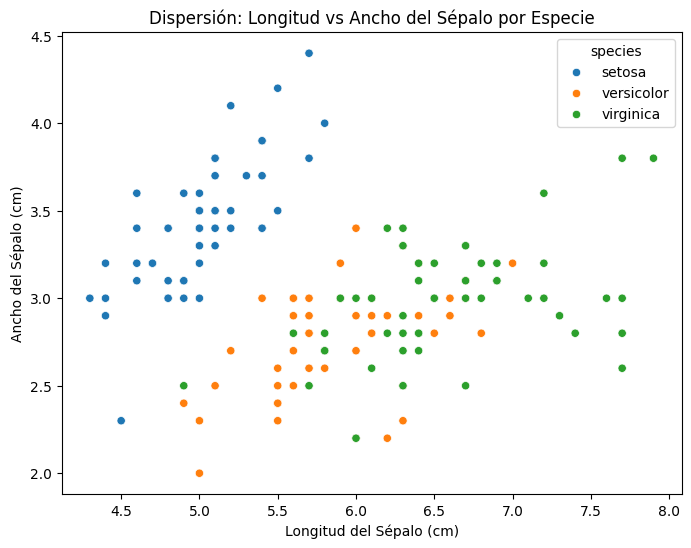

In [96]:
# === Scatter plots ===
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_df, x='longitud del sépalo (cm)', y='ancho del sépalo (cm)', hue='species')
plt.title('Dispersión: Longitud vs Ancho del Sépalo por Especie')
plt.xlabel('Longitud del Sépalo (cm)')
plt.ylabel('Ancho del Sépalo (cm)')
plt.show()

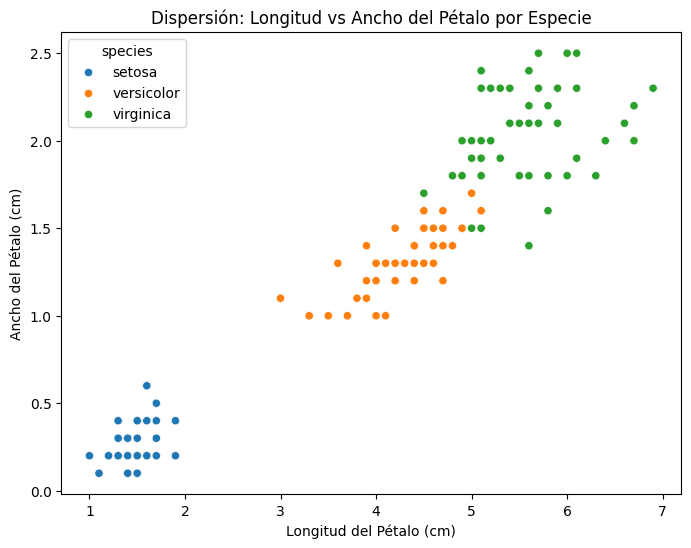

In [97]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_df, x='longitud del pétalo (cm)', y='ancho del pétalo (cm)', hue='species')
plt.title('Dispersión: Longitud vs Ancho del Pétalo por Especie')
plt.xlabel('Longitud del Pétalo (cm)')
plt.ylabel('Ancho del Pétalo (cm)')
plt.show()

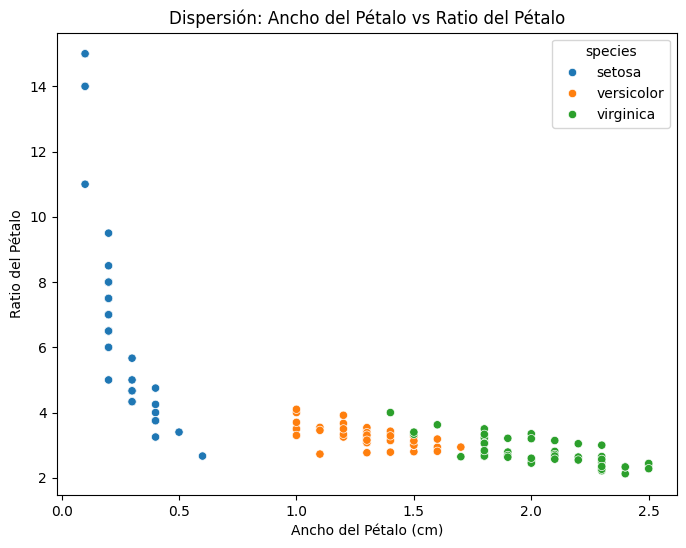

In [98]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_df, x='ancho del pétalo (cm)', y='ratio_petalo', hue='species')
plt.title('Dispersión: Ancho del Pétalo vs Ratio del Pétalo')
plt.xlabel('Ancho del Pétalo (cm)')
plt.ylabel('Ratio del Pétalo')
plt.show()

Conclusiones sobre la Separabilidad (Visualizaciones)

Los diagramas de dispersión nos dan una idea clara de cómo se separan las especies basándose en las diferentes combinaciones de características y ratios:

*   **Longitud vs Ancho del Sépalo:** Se observa cierta superposición entre las especies 'versicolor' y 'virginica', mientras que 'setosa' está bastante bien separada.
*   **Longitud vs Ancho del Pétalo:** Esta combinación de características muestra una separación mucho más clara entre las tres especies. La 'setosa' está completamente separada, y hay una distinción notable entre 'versicolor' y 'virginica', aunque con algo de superposición. El pétalo parece ser más distintivo para la clasificación que el sépalo.
*   **Ratio del Pétalo vs Longitud/Ancho del Pétalo:** Los gráficos que incluyen el `ratio_petalo` también muestran una buena separabilidad, especialmente para 'setosa'. El ratio del pétalo parece ser una característica útil para distinguir las especies, particularmente 'setosa' del resto.

En general, las características del pétalo (longitud, ancho y su ratio) parecen ser más efectivas para separar las especies de Iris que las características del sépalo. La especie 'setosa' es la más fácilmente separable de las otras dos.

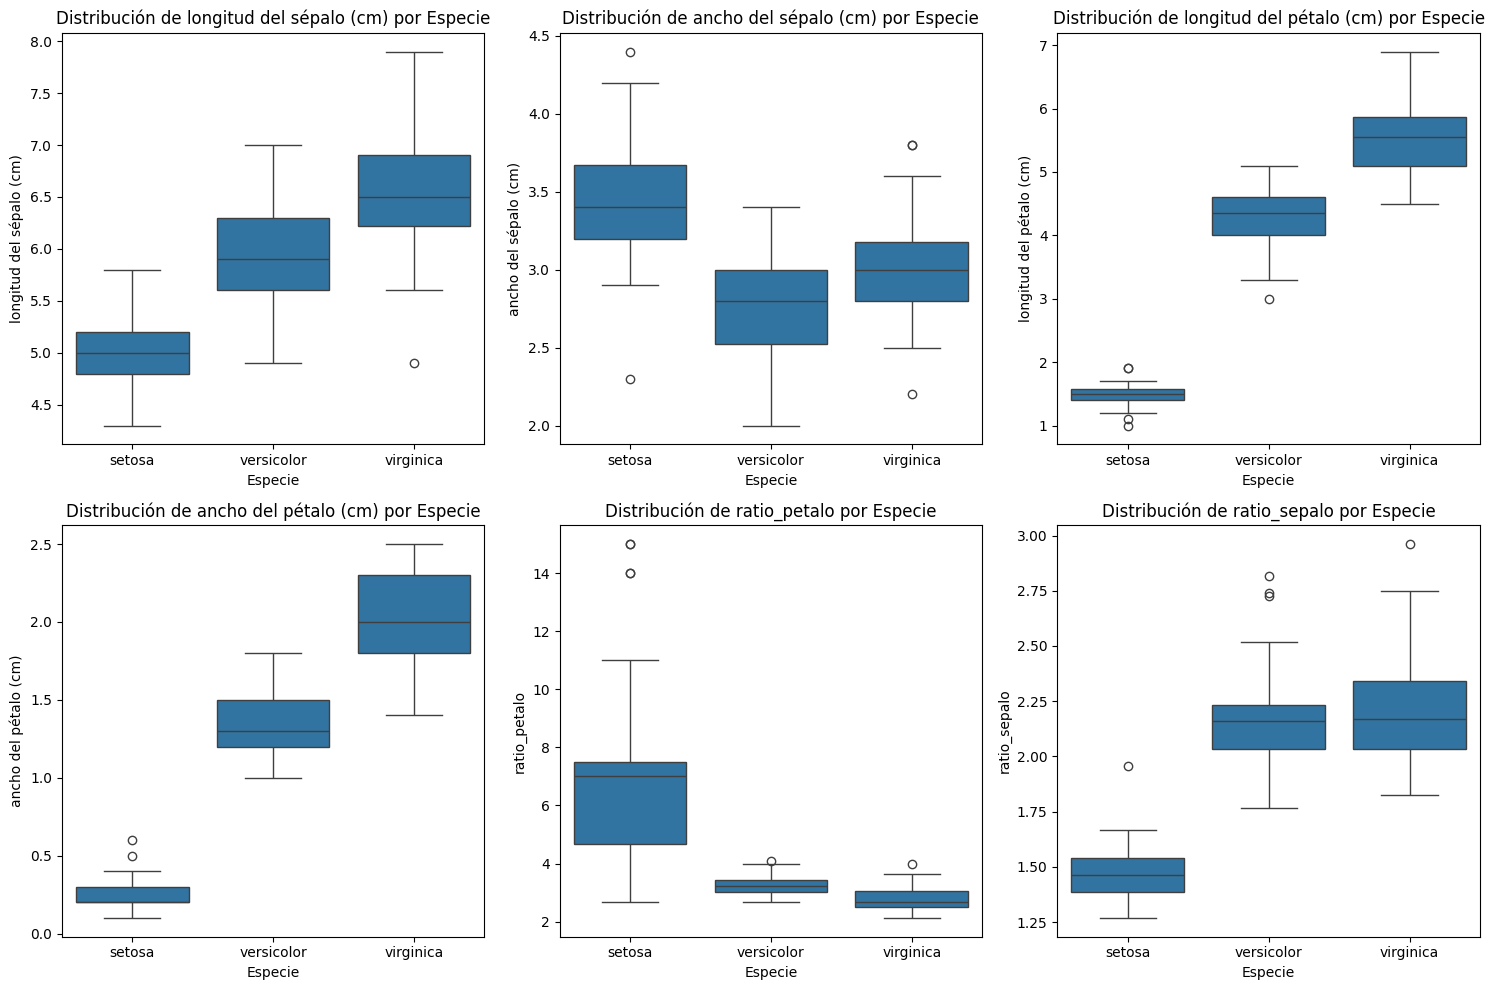

In [99]:
# === Boxplots por especie ===
features_to_plot = [
    'longitud del sépalo (cm)', 'ancho del sépalo (cm)',
    'longitud del pétalo (cm)', 'ancho del pétalo (cm)',
    'ratio_petalo', 'ratio_sepalo'
]
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='species', y=feature, data=iris_df)
    plt.title(f'Distribución de {feature} por Especie')
    plt.xlabel('Especie')
    plt.ylabel(feature)
    plt.tight_layout()
plt.show()

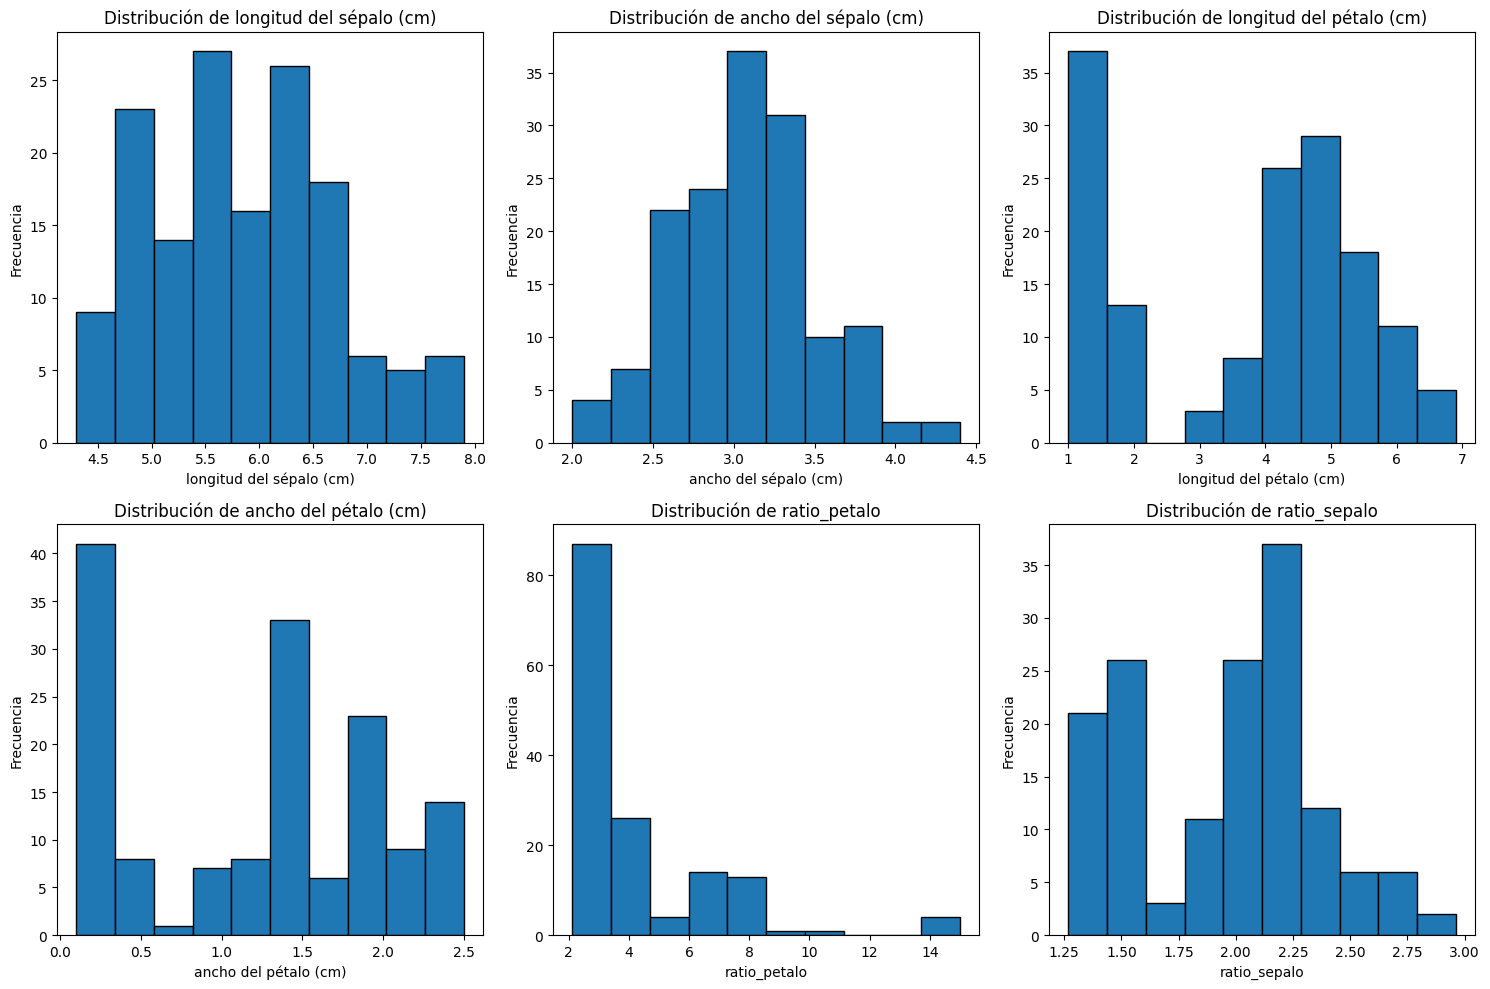

In [100]:
# === Histogramas ===
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    plt.hist(iris_df[feature], bins=10, edgecolor='black')
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
plt.show()

**Experimentando con el número de Bins:**

El número de *bins* en un histograma afecta la granularidad de la visualización. Un número bajo de *bins* agrupa los datos en menos intervalos amplios, mostrando una visión general. Un número alto de *bins* crea más intervalos estrechos, mostrando más detalle pero pudiendo parecer más "ruidoso" si hay pocos datos.

Pueden modificar la celda de código anterior cambiando el valor del parámetro `bins` en la línea `plt.hist()` para ver cómo cambia la visualización.

Modificar el número de bins en la visualización del histograma no afecta el rendimiento de modelos (Random Forest, boosting, Redes Neuronales u otros). Estos modelos trabajan con los datos numéricos brutos o transformados, no con la representación visual del histograma.

Sin embargo, la información que obtienes al observar histogramas con diferentes números de bins sí puede ser muy importante para el feature engineering y la preparación de datos que sí influyen en el rendimiento de estos modelos.

¿Por qué es importante experimentar con los bins desde la perspectiva del modelado?

1. Identificar la Forma de la Distribución: Ver la distribución real de una característica (sesgada, multimodal, uniforme, etc.) ayuda a decidir si necesitas aplicar transformaciones a esa característica. Por ejemplo, si una característica está muy sesgada, aplicar una transformación logarítmica o de raíz cuadrada puede hacerla más "normal" y mejorar el rendimiento de algunos modelos (aunque hay modelos más o menos sensibles a esto). Los histogramas muestran si esa transformación podría ser útil.
2. Detectar Múltiples Modas (Picos): Si un histograma muestra múltiples picos, esto a menudo indica la presencia de subgrupos distintos dentro de tus datos. En el caso del dataset Iris, los histogramas de características como la longitud y el ancho del pétalo claramente muestran distribuciones que reflejan las diferentes especies. Ver estos picos confirma visualmente que esa característica tiene poder discriminatorio y es probable que sea importante para el modelo. Experimentar con bins ayuda a ver estos picos claramente.
3. Identificar Outliers: Un histograma con bins adecuados puede hacer que los valores atípicos (outliers) sean más visibles. Los outliers pueden afectar el rendimiento de algunos modelos. Identificar outliers permite decidir si necesitas manejarlos (eliminarlos, transformarlos o imputarlos).
4. Informar el Binning (Discretización): En algunos casos, podrías decidir discretizar una característica continua dividiéndola en rangos o "bins". Observar el histograma ayuda a decidir dónde establecer esos límites de bins de manera significativa. (Nota: Esto se aplica a la transformación de los datos, no solo a la visualización).

En resumen: Experimentar con el número de bins en un histograma es una herramienta de Análisis Exploratorio de Datos (EDA). No cambia los datos que entran al modelo, pero las observaciones que haces al ver los histogramas te dan información valiosa para tomar decisiones informadas sobre:

* Si aplicar transformaciones a las características.
* Qué características tienen el potencial de separar clases.
* Si necesitas manejar outliers.
* Posibles estrategias de feature engineering (como crear bins en los datos).

Estas decisiones de preparación de datos sí tienen un impacto directo en el rendimiento de tus modelos de Machine Learning.

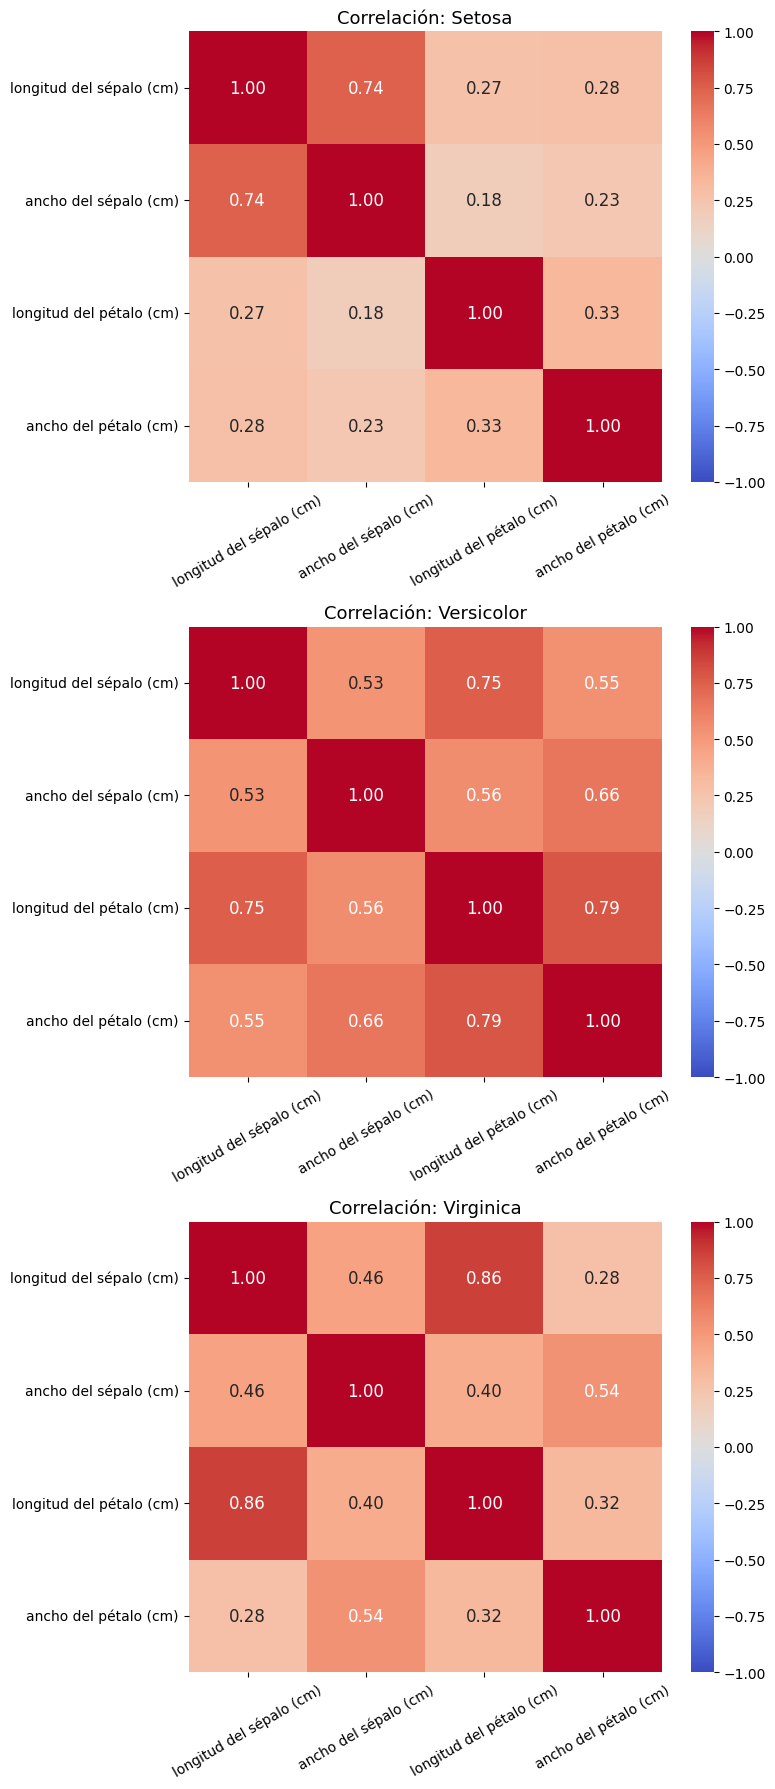

In [101]:
# === Matrices de correlación por especie (4 features originales) ===
features_originales = [
    'longitud del sépalo (cm)', 'ancho del sépalo (cm)',
    'longitud del pétalo (cm)', 'ancho del pétalo (cm)'
]

species_list = iris_df['species'].unique()
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for i, sp in enumerate(species_list):
    corr_sp = iris_df[iris_df['species'] == sp][features_originales].corr()
    sns.heatmap(
        corr_sp,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        vmin=-1, vmax=1,
        annot_kws={"size": 12},
        ax=axes[i]
    )
    axes[i].set_title(f'Correlación: {sp.capitalize()}', fontsize=13)
    axes[i].tick_params(axis='x', labelsize=10, rotation=30)
    axes[i].tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.show()

**Correlaciones Variables por Especie:**

Las correlaciones entre las mismas características varían entre las diferentes especies. Por ejemplo, la correlación entre 'longitud del sépalo' y 'ancho del sépalo' es alta en 'setosa' (alrededor de 0.74), moderada en 'versicolor' (alrededor de 0.53) y moderada en 'virginica' (alrededor de 0.46).

Esto demuestra que las relaciones entre las características no son uniformes en todo el dataset, sino que dependen de la especie.

**Diferencias en la Correlación de Pétalo**
Aunque la longitud y el ancho del pétalo están fuertemente correlacionados en general, las correlaciones específicas dentro de cada especie pueden ser diferentes.

**Relevancia para Feature Engineering**
Estas diferencias en las correlaciones por especie sugieren que ciertas combinaciones o transformaciones de características podrían ser más efectivas para distinguir una especie en particular de las otras, en lugar de buscar una única transformación que funcione para todas. Podría ser útil crear características basadas en las correlaciones específicas observadas dentro de cada grupo.

1. Crear Características Basadas en Umbrales: Observando los box plots y scatter plots, vimos que algunas características (especialmente las del pétalo) tienen rangos que no se solapan o se solapan poco para 'setosa'. Se podrían crear características binarias (0 o 1) basadas en umbrales. Por ejemplo:
es_petalo_pequeño: 1 si 'longitud del pétalo (cm)' es menor que un cierto valor (ej. 2 cm, que parece separar bien a 'setosa'), 0 de lo contrario.
es_ancho_petalo_pequeño: 1 si 'ancho del pétalo (cm)' es menor que un cierto valor (ej. 0.5 cm), 0 de lo contrario.

2. Utilizar los Ratios Existentes y Crear Otros: Ya calculamos ratio_petalo y ratio_sepalo. Estos ratios ya son formas de combinar dos características en una. Se podría evaluar si tienen un buen poder predictivo por sí solos o en combinación con otras características. Podrían pensar en otros ratios si creen que tienen sentido biológico o si observan patrones en los datos.

3. Interacciones de Características: Aunque las matrices de correlación muestran relaciones lineales, podrían explorar interacciones no lineales. Por ejemplo, el área del pétalo (longitud del pétalo * ancho del pétalo) podría ser una característica útil.

4. Características Específicas por Especie: Dado que las correlaciones varían por especie, podrían intentar crear características que capturen estas diferencias. Por ejemplo, una característica que sea la correlación entre longitud y ancho del sépalo solo para esa muestra específica, basada quizás en el cluster al que pertenece.

5. Polinomios o Transformaciones: Si observan relaciones no lineales en los scatter plots, podrían considerar transformaciones polinómicas de las características existentes (ej. longitud_petalo^2).

6. Combinaciones Lineales (Inspirado en PCA): Sin llegar a hacer un PCA completo, podrían probar a combinar linealmente características que parecen importantes o altamente correlacionadas. Por ejemplo, longitud_petalo + ancho_petalo.

---
### Modelo base: Random Forest

In [102]:
# === Modelo: Random Forest con 4 features originales ===
X_original = iris_df[[
    'longitud del sépalo (cm)', 'ancho del sépalo (cm)',
    'longitud del pétalo (cm)', 'ancho del pétalo (cm)'
]]
y = iris_df['species']

X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

model_rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_original.fit(X_train_original, y_train)

y_pred_original = model_rf_original.predict(X_test_original)

print('Evaluación del modelo (Características Originales):')
print('Accuracy:', round(accuracy_score(y_test, y_pred_original), 4))
print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, y_pred_original))
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_original))

Evaluación del modelo (Características Originales):
Accuracy: 0.9

Matriz de Confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [103]:
# === Validación cruzada (5 folds) ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

scores_acc = cross_val_score(rf_cv, X_original, y, cv=cv, scoring='accuracy')
scores_f1  = cross_val_score(rf_cv, X_original, y, cv=cv, scoring='f1_macro')

print('Accuracy por fold:', scores_acc.round(3))
print('F1-macro por fold:', scores_f1.round(3))
print(f'\nAccuracy promedio: {scores_acc.mean():.3f} (+/- {scores_acc.std():.3f})')
print(f'F1-macro promedio: {scores_f1.mean():.3f} (+/- {scores_f1.std():.3f})')

Accuracy por fold: [0.967 0.967 0.933 0.967 0.9  ]
F1-macro por fold: [0.967 0.967 0.933 0.967 0.9  ]

Accuracy promedio: 0.947 (+/- 0.027)
F1-macro promedio: 0.946 (+/- 0.027)


# Un error típico: ¿Qué es el data leakage?

Es cuando, sin querer, el modelo aprende información del conjunto de prueba (test) antes de evaluarlo. Eso pasa si calculás algo con todo el dataset antes de separar en train/test o antes de hacer validación cruzada.

Cómo evitarlo:

* Separar primero, transformar después

1. Hacés train_test_split primero.

2. Calculás promedios, escalados, selección de variables solo con train.

3. Aplicás esas mismas transformaciones al test.

* Usar Pipeline en scikit-learn

* Metés transformaciones y modelo en un mismo pipeline.

* Cuando hacés validación cruzada, scikit-learn aplica fit de cada paso solo en los datos de entrenamiento de cada fold → sin leakage.

Por qué random_state=42 y stratify=y

* random_state=42 → que todos usen la misma división de datos y sea reproducible.

* stratify=y → mantiene las mismas proporciones de clases en train y test.

## ¿Qué NO hacer?

In [104]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Datos
iris = load_iris()
X, y = iris.data, iris.target

# ❌ ERROR: escalar usando TODO el dataset antes de split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # <- acá el test ya "contamina" el escalado

# Split (ya con datos "filtrados" del test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Modelo
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy (con leakage):", accuracy_score(y_test, y_pred))

Accuracy (con leakage): 0.9333333333333333


## ¿Qué hacer?

In [105]:
# Split primero
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Escalar SOLO con train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit en train
X_test_scaled = scaler.transform(X_test)       # transform en test

# Modelo
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

print("Accuracy (sin leakage):", accuracy_score(y_test, y_pred))

Accuracy (sin leakage): 0.9333333333333333


In [106]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scale', StandardScaler()),        # transformación
    ('clf', LogisticRegression(max_iter=1000))  # modelo
])

pipe.fit(X_train, y_train)   # el pipeline ajusta solo con train
y_pred = pipe.predict(X_test)

print("Accuracy (pipeline):", accuracy_score(y_test, y_pred))

Accuracy (pipeline): 0.9333333333333333


El “leakage” fue solo escalar con StandardScaler antes del split (usa medias/desvíos de todo X).

En Iris (pequeño, limpio, balanceado) y con split estratificado, las medias/desvíos de X_train y de X casi no cambian. Por lo que el resultado es un accuracy idéntica (o casi). Eso no significa que el leakage no sea un problema; sólo que en este set/transformación puntual el efecto es minúsculo. En otros casos infla mucho la métrica.

# Ejercicio

**Objetivo**

Explorar el dataset Iris

**Ejercicio de Feature Engineering y Modelado:**

Entrenamos un modelo Random Forest utilizando únicamente las 4 características originales del dataset. Como pudiste observar en los resultados, el rendimiento ya es bastante bueno.

Ahora, te invito a experimentar con diferentes combinaciones de características como *input* para el modelo Random Forest (o incluso otros modelos de clasificación). Podes crear nuevas celdas de código para:

1.  Seleccionar un subconjunto diferente de características del DataFrame `iris_df`, incluyendo los ratios (`ratio_petalo`, `ratio_sepalo`) y las características de ingeniería que creamos (`es_petalo_pequeno`, `es_ancho_petalo_pequeno`, `area_petalo`).
    *   **Ejemplos:**
        *   Solo características del pétalo (`longitud del pétalo (cm)`, `ancho del pétalo (cm)`, `ratio_petalo`, `area_petalo`).
        *   Características originales + ratios.
        *   Solo las características binarias del pétalo (`es_petalo_pequeno`, `es_ancho_petalo_pequeno`).
        *   Todas las características disponibles.
2.  Probar otras alternativas de Feature Engineering: Considerá crear nuevas características usando técnicas que discutimos anteriormente pero que aún no  implementamos, como:
    *   Transformaciones Polinómicas: Crear términos como `longitud_petalo^2` o `ancho_sepalo^3` si observaste relaciones no lineales en los gráficos.
    *   Otras Combinaciones Lineales: Explorar sumas o diferencias de características (`longitud_petalo - ancho_petalo`).
    *   Interacciones Adicionales: Si hay otras combinaciones de características que crees que podrían ser relevantes (por ejemplo, `longitud_sepalo * ancho_sepalo` para el área del sépalo).
3.  Dividir los datos (`X` seleccionado/modificado y `y`) en conjuntos de entrenamiento y prueba nuevamente (usando `train_test_split` con `stratify=y` y el mismo `random_state` para comparaciones justas).
4.  Entrenar **otros modelos de clasificación** (sin incluir Redes Neuronales).
    *   **Modelos de Boosting** (como Gradient Boosting o AdaBoost)
    * Combinación de técnicas: Usar la importancia de las características de un modelo Random Forest entrenado con todas las características disponibles (las originales + las nuevas características creadas a partir del feature engineering) para seleccionar un subconjunto de las características más relevantes. Luego, tomar ese subconjunto de características y utilizarlo para entrenar y ajustar los hiperparámetros de un modelo de Boosting (como Gradient Boosting o XGBoost) para intentar maximizar el rendimiento.
5.  Evaluar el rendimiento de cada modelo. Además de la Accuracy, Matriz de Confusión y Reporte de Clasificación, te invito a considerar otras métricas importantes, como **Precision, Recall, F1-score, Curva ROC (si aplica por clase), Error Tipo I (Falsos Positivos) y Error Tipo II (Falsos Negativos)**.
    *   **Pensá qué métrica priorizar** para este problema específico. ¿Es más importante no clasificar erróneamente una especie particular (evitar Falsos Positivos o Falsos Negativos para una clase)? ¿O la precisión general es suficiente?
6.  Además de comparar el rendimiento, te invito a **analizar la complejidad de cada modelo**. Considerá aspectos como:
    *   **Tiempo de entrenamiento y predicción (Run Time):** ¿Cuánto tardan en entrenarse y hacer predicciones?
    *   **Cantidad de Inputs (Inputs):** ¿Cuántas características utiliza el modelo? (Esto depende de la selección de características que hagas en el paso 1 o 2).
    *   **Interpretabilidad:** ¿Qué tan fácil es entender cómo el modelo llega a sus predicciones? (Por ejemplo, un Árbol de Decisión suele ser más interpretable que un Random Forest o un SVM complejo).

Este ejercicio te ayudará a entender empíricamente cómo las diferentes características, su combinación o transformación, la elección del modelo y la selección de métricas de evaluación pueden influir en el rendimiento y la complejidad de un modelo de clasificación.

Al final, armá una tabla que incluya: Modelo, Features usadas, Accuracy, F1-macro, Tiempo de entrenamiento/predicción, Nº de features y notas de interpretabilidad. Esto facilitará la comparación entre experimentos.